# Riset Ulang Strategi dengan 40 Coin (replikasi notebook 07)

**Kenapa diulang**: notebook 08 menemukan hasil 07 **overfit sebagian** — terutama karena universe
10 coin CSV dipilih dari coin yang *sekarang* sudah besar (SUI menyumbang sebagian besar keuntungan).
Notebook 09 menyiapkan dataset **semua simbol Large+Mid** di `flex_params`.

**Universe utama (40 coin)** = 50 CSV Large/Mid dikurangi:
- 7 stablecoin (median ATR < 1.2%, aturan yang sama dengan `/recommendations`)
- WBETH (ETH yang di-stake, harganya mengikuti ETH → dobel)
- PAXG & XAUT (token emas, bukan crypto) — diuji terpisah sebagai sensitivitas di bagian 6

### Protokol (identik dengan 07, tidak diubah setelah melihat hasil)
- Latih 2021-01 → 2023-12, uji 2024-01 → 2026-06; sinyal di close, eksekusi open besok; biaya 0.15%/sisi.
- Grid, keluarga strategi, dan aturan pemilihan (Calmar latih tertinggi) **sama persis** dengan 07.
- **Uji paling penting (bagian 2)**: parameter hasil 07 diterapkan **apa adanya** ke 40 coin —
  murni out-of-sample dari sisi coin.

In [1]:
import sys
from pathlib import Path
PROJECT_ROOT = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / "src").is_dir())
sys.path.insert(0, str(PROJECT_ROOT)); sys.path.insert(0, str(PROJECT_ROOT / "notebooks"))
import warnings; warnings.filterwarnings("ignore")

import itertools
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from data_source.loader import load_symbol, discover_symbols
from src.databases import get_connection
from src.services.recommendation.service import MIN_VOLATILITY
from research.single_position import (Panel, run, metrics, pretty, f2_target, f1_target, f3_target,
                                      f4_target, BTC)

pd.set_option("display.width", 180); pd.set_option("display.max_columns", 30); pd.set_option("display.max_rows", 80)
TRAIN = ("2021-01-01", "2023-12-31")
TEST = ("2024-01-01", "2026-06-30")
CFG07 = {"Konservatif": dict(ma_n=50, L=14, R=1, tv=0.02, cdd=0.15),
         "Agresif": dict(ma_n=50, L=14, R=1, tv=0.03, cdd=0.15)}
OLD10 = ["ADAUSDT", "AVAXUSDT", "BNBUSDT", "BTCUSDT", "DOGEUSDT", "ETHUSDT", "HBARUSDT", "SOLUSDT", "SUIUSDT", "XRPUSDT"]

with get_connection() as conn:
    lm = [r[0] for r in conn.execute(
        "SELECT value_param FROM flex_params WHERE type_param='SIMBOL_CRYPTO' AND deleted_at IS NULL "
        "AND description IN ('Large','Mid')").fetchall()]
raw = {s: load_symbol(s, "1d", "full") for s in lm if s in set(discover_symbols("1d", "full"))}
P_all = Panel(raw, "2018-01-01", "2026-06-30")
stable = sorted(s for s in raw if P_all.atr_pct[s].median() < MIN_VOLATILITY)
GOLD, DUP = ["PAXGUSDT", "XAUTUSDT"], ["WBETHUSDT"]
UNIV = sorted(s for s in raw if s not in stable + GOLD + DUP)
P = Panel({s: raw[s] for s in UNIV}, "2018-01-01", "2026-06-30")
print(f"Large/Mid: {len(raw)} | stablecoin dibuang: {stable}")
print(f"Universe utama: {len(UNIV)} coin (tanpa {GOLD + DUP})")
print(f"Coin baru dibanding 07: {len(set(UNIV) - set(OLD10))}")


def sim(Pn, c, start, end, **kw):
    tgt = f2_target(Pn, c["ma_n"], c["L"], c["R"])
    size = (c["tv"] / Pn.vol(20)).clip(upper=1) if c["tv"] else None
    return run(Pn, tgt, start, end, size=size, circuit_dd=c["cdd"] or None, **kw)


hold = pd.Series(BTC, index=P.dates)
BENCH = {tag: metrics(*run(P, hold, *per)) for tag, per in (("train", TRAIN), ("test", TEST))}
print(f"BTC hold — latih: {BENCH['train']['total_return']:+.1%} / DD {BENCH['train']['max_dd']:+.1%} | "
      f"uji: {BENCH['test']['total_return']:+.1%} / DD {BENCH['test']['max_dd']:+.1%}, Sharpe {BENCH['test']['sharpe']:.2f}")

Large/Mid: 50 | stablecoin dibuang: ['BFUSDUSDT', 'RLUSDUSDT', 'USD1USDT', 'USDCUSDT', 'USDEUSDT', 'USDSUSDT', 'UUSDT']
Universe utama: 40 coin (tanpa ['PAXGUSDT', 'XAUTUSDT', 'WBETHUSDT'])
Coin baru dibanding 07: 30
BTC hold — latih: +43.7% / DD -76.6% | uji: +32.3% / DD -53.0%, Sharpe 0.47


## 2. Uji replikasi — parameter 07 apa adanya di 40 coin

In [2]:
P10 = Panel({s: raw[s] for s in OLD10}, "2018-01-01", "2026-06-30")
rows = []
for name, c in CFG07.items():
    for label, Pn in (("10 coin (07)", P10), ("40 coin", P)):
        for tag, per in (("latih", TRAIN), ("uji", TEST)):
            m = metrics(*sim(Pn, c, *per))
            rows.append(dict(strategi=name, universe=label, periode=tag, **m))
for tag, per in (("latih", TRAIN), ("uji", TEST)):
    rows.append(dict(strategi="Buy & hold BTC", universe="-", periode=tag, **BENCH["train" if tag == "latih" else "test"]))
rep = pd.DataFrame(rows).set_index(["strategi", "universe", "periode"])
pretty(rep[["total_return", "cagr", "max_dd", "sharpe", "n_trades", "win_rate", "exposure"]],
       pct=["total_return", "cagr", "max_dd", "win_rate", "exposure"], dec=["sharpe"])

total_return     cagr  max_dd sharpe  n_trades win_rate exposure
strategi       universe     periode                                                                 
Konservatif    10 coin (07) latih        +520.1%   +83.9%  -33.1%   1.91       121   +52.1%   +42.4%
                            uji          +204.0%   +56.2%  -30.8%   1.37       124   +39.5%   +44.4%
               40 coin      latih        +340.5%   +64.1%  -30.6%   1.54       173   +43.9%   +44.6%
                            uji           +28.8%   +10.7%  -38.3%   0.47       165   +40.6%   +46.6%
Agresif        10 coin (07) latih       +1288.2%  +140.7%  -33.8%   2.01       126   +51.6%   +41.8%
                            uji          +354.9%   +83.6%  -39.1%   1.49       105   +39.0%   +37.7%
               40 coin      latih        +632.0%   +94.4%  -34.2%   1.56       160   +43.8%   +41.6%
                            uji           +73.8%   +24.8%  -46.1%   0.70       148   +41.2%   +42.8%
Buy & hold BTC -            latih         +43.7%   +12.9%  -76.6%   0.51         1  +100.0%   +99.9%
                            uji           +32.3%   +11.9%  -53.0%   0.47         1  +100.0%   +99.9%

In [3]:
yr = {}
b = P.close[BTC]["2021-01-01":"2026-06-30"]
yr["Buy & hold BTC"] = b.groupby(b.index.year).agg(lambda s: s.iloc[-1] / s.iloc[0] - 1)
for name, c in CFG07.items():
    _, eq = sim(P, c, "2021-01-01", "2026-06-30")
    yr[f"{name} (40 coin)"] = eq.groupby(eq.index.year).agg(lambda s: s.iloc[-1] / s.iloc[0] - 1)
    _, eq = sim(P10, c, "2021-01-01", "2026-06-30")
    yr[f"{name} (10 coin, 07)"] = eq.groupby(eq.index.year).agg(lambda s: s.iloc[-1] / s.iloc[0] - 1)
per_year = pd.DataFrame(yr).T
per_year.columns = [f"{y}{' (s/d Jun)' if y == 2026 else ''}" for y in per_year.columns]
print("Return per tahun:")
per_year.map(lambda v: f"{v:+.0%}")

Return per tahun:


,2021,2022,2023,2024,2025,2026 (s/d Jun)
Buy & hold BTC,+58%,-65%,+154%,+112%,-7%,-34%
Konservatif (40 coin),+187%,-1%,+55%,+72%,-7%,-19%
"Konservatif (10 coin, 07)",+235%,-12%,+110%,+159%,+14%,+3%
Agresif (40 coin),+358%,-14%,+85%,+116%,+4%,-23%
"Agresif (10 coin, 07)",+472%,-0%,+143%,+444%,-13%,-1%


## 3. Screening 4 keluarga strategi (sama dengan 07)

F1 & F3 hanya memakai BTC → tidak terpengaruh universe. F2 & F4 memakai semua coin.

In [4]:
def evaluate(family, params, target, **kw):
    r = dict(family=family, params=params)
    for tag, per in (("tr", TRAIN), ("te", TEST)):
        r.update({f"{tag}_{k}": v for k, v in metrics(*run(P, target, *per, **kw)).items()})
    return r

rows = []
for n in (20, 30, 50, 75, 100, 150, 200):
    for kind in ("sma", "ema"):
        for trail in (None, 3.0):
            rows.append(evaluate("F1 tren BTC", f"{kind}{n} trail={trail}", f1_target(P, n, kind), trail_atr=trail))
for n, L in itertools.product((50, 100), (14, 30, 60)):
    for trail in (None, 3.0):
        rows.append(evaluate("F2 tren+momentum", f"MA{n} L{L} trail={trail}", f2_target(P, n, L, 1), trail_atr=trail))
for N, M in itertools.product((20, 40, 55), (10, 20)):
    rows.append(evaluate("F3 breakout BTC", f"N{N} M{M}", f3_target(P, N, M)))
for k, th, H in itertools.product((2, 3), (10, 20), (3, 5)):
    rows.append(evaluate("F4 dip dlm uptrend", f"RSI{k}<{th} H{H}", f4_target(P, k, th, H), stop_pct=-0.08))
screen = pd.DataFrame(rows)
summary = screen.groupby("family").agg(
    n=("params", "size"), train_sharpe_median=("tr_sharpe", "median"), test_sharpe_median=("te_sharpe", "median"),
    test_return_median=("te_total_return", "median"), test_dd_median=("te_max_dd", "median"),
    pct_test_sharpe_beat_btc=("te_sharpe", lambda s: (s > BENCH["test"]["sharpe"]).mean()))
print("Keluarga diurutkan menurut median Sharpe LATIH (kriteria pemilihan):")
pretty(summary.sort_values("train_sharpe_median", ascending=False),
       pct=["test_return_median", "test_dd_median", "pct_test_sharpe_beat_btc"], dec=["train_sharpe_median", "test_sharpe_median"])

Keluarga diurutkan menurut median Sharpe LATIH (kriteria pemilihan):


,n,train_sharpe_median,test_sharpe_median,test_return_median,test_dd_median,pct_test_sharpe_beat_btc
family,,,,,,
F2 tren+momentum,12,1.16,0.50,+13.1%,-77.5%,+58.3%
F1 tren BTC,28,0.79,0.45,+26.5%,-34.5%,+50.0%
F3 breakout BTC,6,0.52,0.35,+15.8%,-36.7%,+16.7%
F4 dip dlm uptrend,8,-0.17,-1.54,-79.9%,-81.1%,+0.0%


## 4. Grid F2 (144 kombinasi, sama dengan 07) + pemilihan dari data latih

In [5]:
GRID = list(itertools.product((50, 100), (14, 30), (1, 3, 7), (0.0, 0.02, 0.03), (0.0, 0.15, 0.20, 0.25)))
KEYS = ["ma_n", "L", "R", "tv", "cdd"]
rows = []
for combo in GRID:
    c = dict(zip(KEYS, combo))
    r = dict(c)
    for tag, per in (("tr", TRAIN), ("te", TEST)):
        r.update({f"{tag}_{k}": v for k, v in metrics(*sim(P, c, *per)).items()})
    rows.append(r)
grid = pd.DataFrame(rows)
print(f"{len(grid)} kombinasi | periode uji: {(grid.te_sharpe > BENCH['test']['sharpe']).mean():.0%} Sharpe > BTC, "
      f"{(grid.te_total_return > 0).mean():.0%} untung, {(grid.te_max_dd > -0.35).mean():.0%} DD lebih kecil dari -35%")
marg = []
for c in KEYS:
    g = grid.groupby(c)[["tr_sharpe", "tr_max_dd", "te_sharpe", "te_total_return", "te_max_dd"]].median()
    g.index = [f"{c} = {v}" for v in g.index]
    marg.append(g)
pretty(pd.concat(marg), pct=["tr_max_dd", "te_total_return", "te_max_dd"], dec=["tr_sharpe", "te_sharpe"])

144 kombinasi | periode uji: 43% Sharpe > BTC, 68% untung, 17% DD lebih kecil dari -35%


,tr_sharpe,tr_max_dd,te_sharpe,te_total_return,te_max_dd
ma_n = 50,1.08,-47.3%,0.31,+6.8%,-49.6%
ma_n = 100,0.77,-56.0%,0.49,+29.1%,-40.5%
L = 14,0.82,-50.8%,0.35,+13.8%,-46.5%
L = 30,1.05,-51.6%,0.44,+23.8%,-44.7%
R = 1,1.14,-45.6%,0.32,+10.0%,-49.9%
R = 3,0.95,-51.3%,0.21,-3.6%,-47.8%
R = 7,0.46,-56.2%,0.60,+52.1%,-38.8%
tv = 0.0,0.91,-67.2%,0.47,+18.8%,-61.8%
tv = 0.02,1.11,-37.5%,0.34,+15.9%,-37.8%
tv = 0.03,0.90,-51.1%,0.34,+15.4%,-46.2%


In [6]:
best = grid.sort_values("tr_calmar", ascending=False).iloc[0]
CFG = {"Agresif (baru)": {k: (int(best[k]) if k in ("ma_n", "L", "R") else float(best[k])) for k in KEYS}}
CFG["Konservatif (baru)"] = {**CFG["Agresif (baru)"], "tv": 0.02}
print("Terpilih dari data latih 40 coin:", CFG)
SHOW = KEYS + ["tr_total_return", "tr_max_dd", "tr_sharpe", "tr_calmar", "te_total_return", "te_max_dd", "te_sharpe", "te_n_trades"]
pretty(grid.sort_values("tr_calmar", ascending=False).head(10)[SHOW],
       pct=["tr_total_return", "tr_max_dd", "te_total_return", "te_max_dd"], dec=["tr_sharpe", "tr_calmar", "te_sharpe"])

Terpilih dari data latih 40 coin: {'Agresif (baru)': {'ma_n': 50, 'L': 30, 'R': 1, 'tv': 0.0, 'cdd': 0.0}, 'Konservatif (baru)': {'ma_n': 50, 'L': 30, 'R': 1, 'tv': 0.02, 'cdd': 0.0}}


,ma_n,L,R,tv,cdd,tr_total_return,tr_max_dd,tr_sharpe,tr_calmar,te_total_return,te_max_dd,te_sharpe,te_n_trades
36,50,30,1,0.00,0.00,+2452.8%,-59.2%,1.47,3.30,-21.7%,-77.7%,0.32,134
48,50,30,3,0.00,0.00,+2494.9%,-67.3%,1.48,2.92,-21.8%,-74.3%,0.30,82
9,50,14,1,0.03,0.15,+632.0%,-34.2%,1.56,2.76,+73.8%,-46.1%,0.70,148
120,100,30,3,0.00,0.00,+1483.0%,-67.7%,1.38,2.24,+271.6%,-66.4%,1.00,75
108,100,30,1,0.00,0.00,+1451.4%,-67.1%,1.36,2.23,+85.5%,-61.4%,0.71,130
10,50,14,1,0.03,0.20,+580.9%,-40.3%,1.49,2.23,+17.2%,-56.6%,0.37,159
5,50,14,1,0.02,0.15,+340.5%,-30.6%,1.54,2.09,+28.8%,-38.3%,0.47,165
13,50,14,3,0.00,0.15,+539.9%,-41.6%,1.19,2.06,-6.9%,-55.4%,0.20,67
39,50,30,1,0.00,0.25,+897.9%,-59.3%,1.22,1.95,-4.6%,-63.5%,0.32,86
71,50,30,7,0.03,0.25,+373.5%,-36.0%,1.37,1.89,-18.3%,-54.3%,-0.00,55


## 5. Uji ketahanan

In [7]:
ALL = {**{f"{k} (07)": v for k, v in CFG07.items()}, **CFG}
rows, tr_test, eq_test = [], {}, {}
for name, c in ALL.items():
    tr, eq = sim(P, c, *TEST)
    tr_test[name], eq_test[name] = tr, eq
    rows.append(dict(strategi=name, uji="uji", **metrics(tr, eq), avg_hold=tr["days"].mean() if len(tr) else np.nan))
    rows.append(dict(strategi=name, uji="uji, biaya 2x", **metrics(*sim(P, c, *TEST, cost=0.003))))
rows.append(dict(strategi="Tren BTC MA50 (F1)", uji="uji", **metrics(*run(P, f1_target(P, 50), *TEST))))
rows.append(dict(strategi="Buy & hold BTC", uji="uji", **BENCH["test"]))
pretty(pd.DataFrame(rows).set_index(["strategi", "uji"])[["total_return", "max_dd", "sharpe", "n_trades", "win_rate", "exposure", "avg_hold"]],
       pct=["total_return", "max_dd", "win_rate", "exposure"], dec=["sharpe", "avg_hold"])

total_return  max_dd sharpe  n_trades win_rate exposure avg_hold
strategi           uji                                                                           
Konservatif (07)   uji                 +28.8%  -38.3%   0.47       165   +40.6%   +46.6%     2.58
                   uji, biaya 2x        -0.6%  -46.7%   0.16       158   +36.7%   +45.3%        -
Agresif (07)       uji                 +73.8%  -46.1%   0.70       148   +41.2%   +42.8%     2.64
                   uji, biaya 2x        -7.6%  -49.1%   0.12       131   +36.6%   +36.7%        -
Agresif (baru)     uji                 -21.7%  -77.7%   0.32       134   +37.3%   +53.8%     3.66
                   uji, biaya 2x       -47.7%  -82.7%   0.14       134   +33.6%   +53.8%        -
Konservatif (baru) uji                  +6.0%  -43.4%   0.23       134   +37.3%   +53.8%     3.66
                   uji, biaya 2x       -13.8%  -50.4%  -0.01       134   +33.6%   +53.8%        -
Tren BTC MA50 (F1) uji                 +64.8%  -26.7%   0.77        30   +23.3%   +53.8%        -
Buy & hold BTC     uji                 +32.3%  -53.0%   0.47         1  +100.0%   +99.9%        -

In [8]:
# Kontribusi per coin: return gabungan trade per coin di periode uji (Konservatif 07)
name = "Konservatif (07)"
t = tr_test[name]
contrib = t.groupby("sym").agg(trade=("ret", "size"), hari=("days", "sum"),
                               return_gabungan=("ret", lambda r: (1 + r).prod() - 1)).sort_values("return_gabungan", ascending=False)
print(f"{name} — kontribusi per coin (periode uji), 8 teratas & 5 terbawah:")
top = contrib.head(8)
bottom = contrib.tail(5)
pretty(pd.concat([top, bottom]), pct=["return_gabungan"])

Konservatif (07) — kontribusi per coin (periode uji), 8 teratas & 5 terbawah:


,trade,hari,return_gabungan
sym,,,
PEPEUSDT,7,28,+138.9%
DOGEUSDT,5,23,+70.3%
HBARUSDT,1,1,+59.4%
XRPUSDT,7,20,+47.1%
QNTUSDT,5,26,+38.4%
TAOUSDT,14,30,+29.6%
ARBUSDT,3,15,+11.7%
WLDUSDT,3,13,+6.6%
BNBUSDT,9,24,-14.5%


In [9]:
# Leave-one-out untuk 5 penyumbang terbesar: apakah hasil bertumpu pada 1 coin?
loo = {}
for s in contrib.head(5).index:
    Pl = Panel({k: raw[k] for k in UNIV if k != s}, "2018-01-01", "2026-06-30")
    loo[f"tanpa {s}"] = {n: metrics(*sim(Pl, c, *TEST)) for n, c in ALL.items()}
loo_df = pd.DataFrame({k: {n: v[n]["total_return"] for n in ALL} for k, v in loo.items()}).T
print("Return periode uji tanpa penyumbang terbesar:")
loo_df.map(lambda v: f"{v:+.0%}")

Return periode uji tanpa penyumbang terbesar:


,Konservatif (07),Agresif (07),Agresif (baru),Konservatif (baru)
tanpa PEPEUSDT,+14%,+46%,-75%,-17%
tanpa DOGEUSDT,+34%,-13%,-54%,-30%
tanpa HBARUSDT,+11%,+40%,-6%,+9%
tanpa XRPUSDT,+13%,+133%,-37%,-11%
tanpa QNTUSDT,+13%,+45%,-9%,+15%


## 6. Sensitivitas: universe dengan token emas (PAXG, XAUT)

In [10]:
P_gold = Panel({s: raw[s] for s in UNIV + GOLD}, "2018-01-01", "2026-06-30")
rows = []
for name, c in ALL.items():
    for label, Pn in (("tanpa emas", P), ("dengan emas", P_gold)):
        m = metrics(*sim(Pn, c, *TEST))
        rows.append(dict(strategi=name, universe=label, total_return=m["total_return"], max_dd=m["max_dd"], sharpe=m["sharpe"]))
pretty(pd.DataFrame(rows).set_index(["strategi", "universe"]), pct=["total_return", "max_dd"], dec=["sharpe"])

total_return  max_dd sharpe
strategi           universe                               
Konservatif (07)   tanpa emas        +28.8%  -38.3%   0.47
                   dengan emas       +47.4%  -29.1%   0.64
Agresif (07)       tanpa emas        +73.8%  -46.1%   0.70
                   dengan emas        -5.3%  -47.4%   0.13
Agresif (baru)     tanpa emas        -21.7%  -77.7%   0.32
                   dengan emas       +90.5%  -62.6%   0.71
Konservatif (baru) tanpa emas         +6.0%  -43.4%   0.23
                   dengan emas       +54.6%  -26.8%   0.71

## 7. Validasi coin produksi (DB) — sama dengan 07

In [11]:
from src.services.recommendation import repository as repo
db = repo.find_all_candles("1d")
cats = repo.find_symbol_categories(("Large", "Mid"))
univ_db = {s: db[s] for s in cats if s in db}
P0 = Panel(univ_db, "2025-02-26", "2026-07-18")
univ_db = {s: d for s, d in univ_db.items() if P0.atr_pct[s].median() >= MIN_VOLATILITY and s not in GOLD + DUP}
Pd = Panel(univ_db, "2025-02-26", "2026-07-18")
VAL = ("2025-04-20", "2026-07-11")
print(f"Universe DB tanpa emas ({len(univ_db)} coin)")
rows, eq_val = [], {}
for name, c in ALL.items():
    tr, eq = sim(Pd, c, *VAL)
    eq_val[name] = eq
    rows.append(dict(strategi=name, **metrics(tr, eq)))
hb = pd.Series(BTC, index=Pd.dates)
rows.append(dict(strategi="Tren BTC MA50 (F1)", **metrics(*run(Pd, f1_target(Pd, 50), *VAL))))
rows.append(dict(strategi="Buy & hold BTC", **metrics(*run(Pd, hb, *VAL))))
pretty(pd.DataFrame(rows).set_index("strategi")[["total_return", "max_dd", "sharpe", "n_trades", "win_rate"]],
       pct=["total_return", "max_dd", "win_rate"], dec=["sharpe"])

Universe DB tanpa emas (21 coin)


,total_return,max_dd,sharpe,n_trades,win_rate
strategi,,,,,
Konservatif (07),+5.8%,-28.3%,0.30,63,+41.3%
Agresif (07),+16.6%,-32.2%,0.52,55,+45.5%
Agresif (baru),-10.7%,-35.2%,0.00,64,+40.6%
Konservatif (baru),+4.5%,-20.8%,0.27,64,+40.6%
Tren BTC MA50 (F1),+9.1%,-26.2%,0.42,14,+28.6%
Buy & hold BTC,-24.9%,-53.0%,-0.35,1,+0.0%


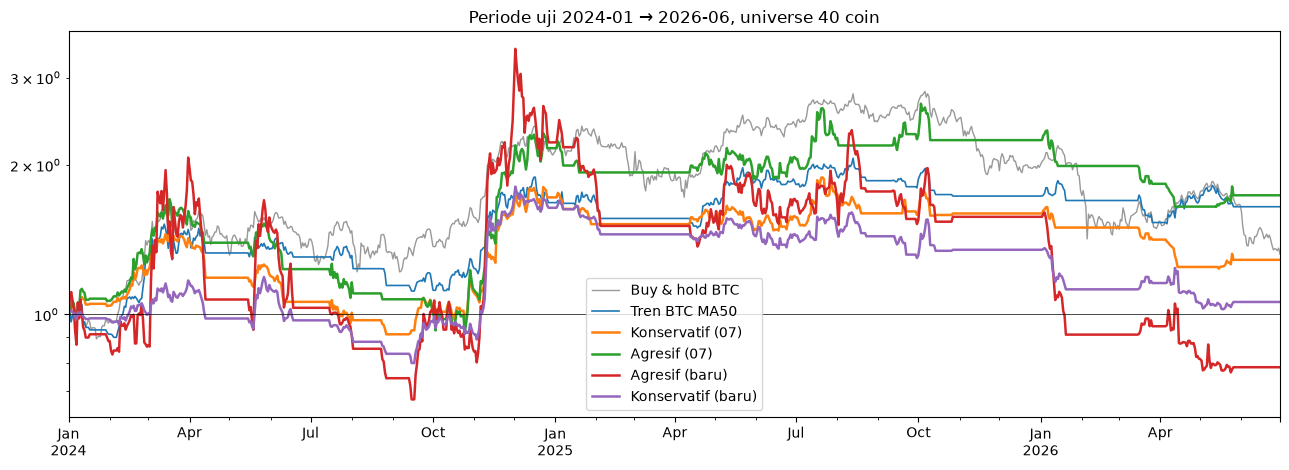

In [12]:
fig, ax = plt.subplots(figsize=(13, 4.8))
_, e = run(P, hold, *TEST); e.plot(ax=ax, color="#999999", lw=1, label="Buy & hold BTC")
_, e = run(P, f1_target(P, 50), *TEST); e.plot(ax=ax, lw=1.2, label="Tren BTC MA50")
for name, e in eq_test.items():
    e.plot(ax=ax, lw=1.8, label=name)
ax.set_yscale("log"); ax.axhline(1, color="black", lw=0.5)
ax.set_title("Periode uji 2024-01 → 2026-06, universe 40 coin"); ax.legend()
plt.tight_layout(); plt.show()

## Kesimpulan — keunggulan rotasi momentum **tidak bertahan** di universe 40 coin

### 1. Parameter 07 di 40 coin (uji replikasi, murni out-of-sample dari sisi coin)
| Strategi (periode uji) | 10 coin (07) | **40 coin** | Biaya 2× (40 coin) |
|---|---|---|---|
| Konservatif | +204%, DD −31%, Sharpe 1.37 | **+28.8%, DD −38%, Sharpe 0.47** | −0.6% |
| Agresif | +355%, DD −39%, Sharpe 1.49 | **+73.8%, DD −46%, Sharpe 0.70** | −7.6% |
| Tren BTC MA50 (F1) | +64.8%, DD −26.7%, Sharpe 0.77 | **sama** (hanya BTC) | – |
| Buy & hold BTC | +32.3%, DD −53%, Sharpe 0.47 | sama | – |

Konservatif 07 di 40 coin **setara dengan buy & hold BTC** (Sharpe 0.47 = 0.47) dan hilang sama sekali
kalau biaya lebih tinggi. Hasil 10 coin sebagian besar berasal dari memilih coin yang sudah sukses.

### 2. Proses pemilihan parameter gagal
Mengulang protokol 07 persis (grid 144, pilih Calmar latih tertinggi) di 40 coin memilih
`MA50 L30 R1 tanpa sizing/circuit` → latih +2.453%, **uji −21.7% dengan drawdown −78%**.
Hanya 43% kombinasi mengalahkan Sharpe BTC di uji (07: 97%). Ini bukti kuat bahwa
**menyetel rotasi momentum = mencocokkan kebetulan**.

### 3. Yang bertahan: filter tren
- **F1 (pegang BTC saat close > MA50, else cash)** kini strategi dengan Sharpe tertinggi di uji
  (0.77) dan drawdown terkecil (−26.7% vs −53%), dengan hanya 30 trade (biaya rendah).
  F1 tidak memilih coin, jadi kebal terhadap bias pemilihan universe.
- Di validasi DB, F1 +9.1% vs BTC −24.9%; strategi rotasi +4.5% s/d +16.6% (tidak lebih baik secara konsisten).
- Semua varian rotasi tetap melindungi modal di 2022 (−1% s/d −14% vs BTC −65%) — itu jasa filter
  tren, bukan jasa pemilihan coin.

### 4. Catatan lain
- Rebalance mingguan (`R = 7`) median-nya paling baik di uji (Sharpe 0.60) — konsisten dengan uji nol di
  notebook 08, tapi ini **dilihat dari data uji**, jadi hanya hipotesis untuk diuji terpisah.
- Token emas (PAXG/XAUT) memperbaiki sebagian varian tapi memperburuk yang lain → tidak konsisten.
- Rotasi sangat sensitif biaya: ~150 trade dalam 2,5 tahun.

**Audit statistik lengkap (PBO, Deflated Sharpe, walk-forward, uji nol) ada di notebook 11.**